In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define transform: convert images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Download and load MNIST
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 67.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 18.0MB/s]

Training samples : 60000
Test samples     : 10000


In [3]:
class Encoder(nn.Module):
    """
    Encodes input image x into latent distribution parameters:
    mu (mean) and log_var (log variance).
    """
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(Encoder, self).__init__()
        self.fc1     = nn.Linear(input_dim, hidden_dim)
        self.fc_mu   = nn.Linear(hidden_dim, latent_dim)   # Output: mean (μ)
        self.fc_logv = nn.Linear(hidden_dim, latent_dim)   # Output: log variance log(σ²)

    def forward(self, x):
        x       = F.relu(self.fc1(x))
        mu      = self.fc_mu(x)
        log_var = self.fc_logv(x)
        return mu, log_var

In [4]:
def reparameterize(mu, log_var):
    """
    Reparameterization Trick:
    z = mu + sigma * epsilon,  where epsilon ~ N(0, I)

    This makes sampling differentiable so gradients can flow
    back through the stochastic node.
    """
    std     = torch.exp(0.5 * log_var)   # sigma = exp(0.5 * log(σ²))
    epsilon = torch.randn_like(std)       # epsilon ~ N(0, 1)
    z       = mu + std * epsilon          # Latent vector z
    return z

In [5]:
class Decoder(nn.Module):
    """
    Decodes latent vector z back into image space.
    Uses Sigmoid to output pixel values in [0, 1].
    """
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super(Decoder, self).__init__()
        self.fc1  = nn.Linear(latent_dim, hidden_dim)
        self.fc2  = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        z      = F.relu(self.fc1(z))
        x_recon = torch.sigmoid(self.fc2(z))   # Output pixels in [0, 1]
        return x_recon

In [6]:
class VAE(nn.Module):
    """
    Full Variational Autoencoder:
    Encoder → Reparameterize → Decoder
    """
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        # Flatten image: (B, 1, 28, 28) → (B, 784)
        x = x.view(x.size(0), -1)

        # Encode → get distribution parameters
        mu, log_var = self.encoder(x)

        # Reparameterize → sample latent vector z
        z = reparameterize(mu, log_var)

        # Decode → reconstruct input
        x_recon = self.decoder(z)

        return x_recon, mu, log_var

In [7]:
def vae_loss(x_recon, x_original, mu, log_var):
    """
    Total VAE Loss = Reconstruction Loss + KL Divergence Loss

    1. Reconstruction Loss (Binary Cross Entropy):
       Measures how well the decoder reconstructs the input.

    2. KL Divergence Loss:
       Regularizes the latent space by pushing q(z|x)
       toward the prior p(z) = N(0, I).
       KL = -0.5 * sum(1 + log(σ²) - μ² - σ²)
    """
    # Flatten original for comparison
    x_original = x_original.view(x_original.size(0), -1)

    # Normalize pixel values to [0,1] (from [-1,1])
    x_original = (x_original + 1) / 2.0

    # Reconstruction Loss
    recon_loss = F.binary_cross_entropy(x_recon, x_original, reduction='sum')

    # KL Divergence Loss
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Total Loss
    total_loss = recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss

In [8]:
# ── Hyperparameters ──────────────────────────────────────
INPUT_DIM  = 784
HIDDEN_DIM = 400
LATENT_DIM = 2
EPOCHS     = 20
LR         = 1e-3

# ── Model, Optimizer ─────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ── History for plotting ──────────────────────────────────
history = {"total": [], "recon": [], "kl": []}

print(f"Training on: {device}")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_total = 0.0
    epoch_recon = 0.0
    epoch_kl    = 0.0

    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(device)

        # ── Forward Pass ──────────────────────────────────
        x_recon, mu, log_var = model(x)

        # ── Compute Loss ──────────────────────────────────
        total_loss, recon_loss, kl_loss = vae_loss(x_recon, x, mu, log_var)

        # ── Backward Pass & Weight Update ─────────────────
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_total += total_loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()

    # Average over dataset
    n = len(train_dataset)
    avg_total = epoch_total / n
    avg_recon = epoch_recon / n
    avg_kl    = epoch_kl    / n

    history["total"].append(avg_total)
    history["recon"].append(avg_recon)
    history["kl"].append(avg_kl)

    print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
          f"Total Loss: {avg_total:8.4f} | "
          f"Recon Loss: {avg_recon:8.4f} | "
          f"KL Loss: {avg_kl:7.4f}")

print("=" * 55)
print("Training Complete!")

Training on: cuda
Epoch [01/20] | Total Loss: 186.5257 | Recon Loss: 179.7907 | KL Loss:  6.7349
Epoch [02/20] | Total Loss: 167.9090 | Recon Loss: 162.8378 | KL Loss:  5.0712
Epoch [03/20] | Total Loss: 162.9079 | Recon Loss: 157.7011 | KL Loss:  5.2068
Epoch [04/20] | Total Loss: 160.5471 | Recon Loss: 155.2073 | KL Loss:  5.3398
Epoch [05/20] | Total Loss: 158.7650 | Recon Loss: 153.3492 | KL Loss:  5.4158
Epoch [06/20] | Total Loss: 157.4268 | Recon Loss: 151.9018 | KL Loss:  5.5251
Epoch [07/20] | Total Loss: 156.3179 | Recon Loss: 150.7411 | KL Loss:  5.5768
Epoch [08/20] | Total Loss: 155.3964 | Recon Loss: 149.7440 | KL Loss:  5.6524
Epoch [09/20] | Total Loss: 154.6370 | Recon Loss: 148.9153 | KL Loss:  5.7216
Epoch [10/20] | Total Loss: 153.9255 | Recon Loss: 148.1577 | KL Loss:  5.7678
Epoch [11/20] | Total Loss: 153.3358 | Recon Loss: 147.5264 | KL Loss:  5.8093
Epoch [12/20] | Total Loss: 152.7841 | Recon Loss: 146.9459 | KL Loss:  5.8382
Epoch [13/20] | Total Loss: 152.41

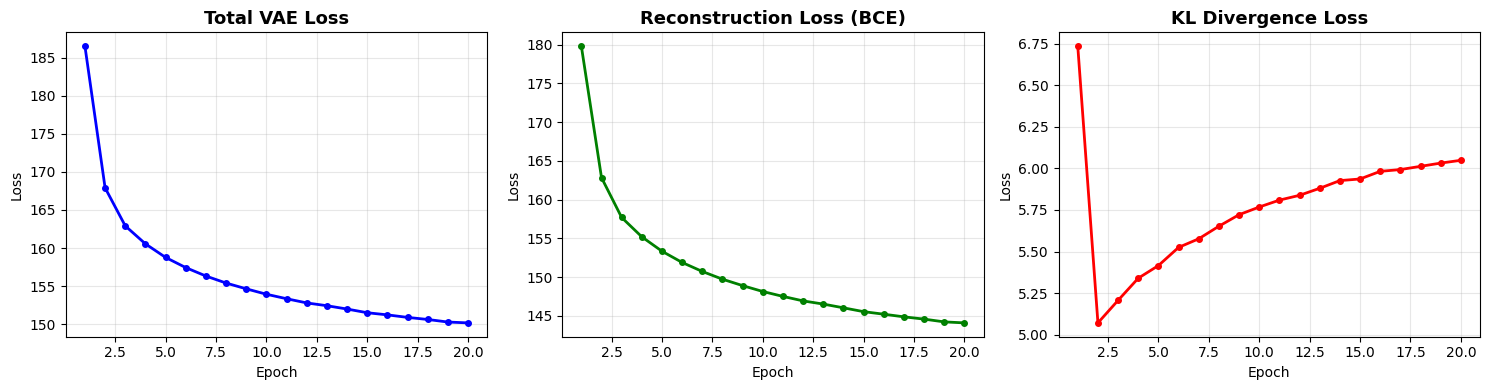

Loss curves saved.


In [9]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(15, 4))

# Plot 1: Total Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["total"], 'b-o', markersize=4, linewidth=2)
plt.title("Total VAE Loss", fontsize=13, fontweight='bold')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

# Plot 2: Reconstruction Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["recon"], 'g-o', markersize=4, linewidth=2)
plt.title("Reconstruction Loss (BCE)", fontsize=13, fontweight='bold')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

# Plot 3: KL Divergence Loss
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["kl"], 'r-o', markersize=4, linewidth=2)
plt.title("KL Divergence Loss", fontsize=13, fontweight='bold')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vae_loss_curves.png", dpi=150)
plt.show()
print("Loss curves saved.")

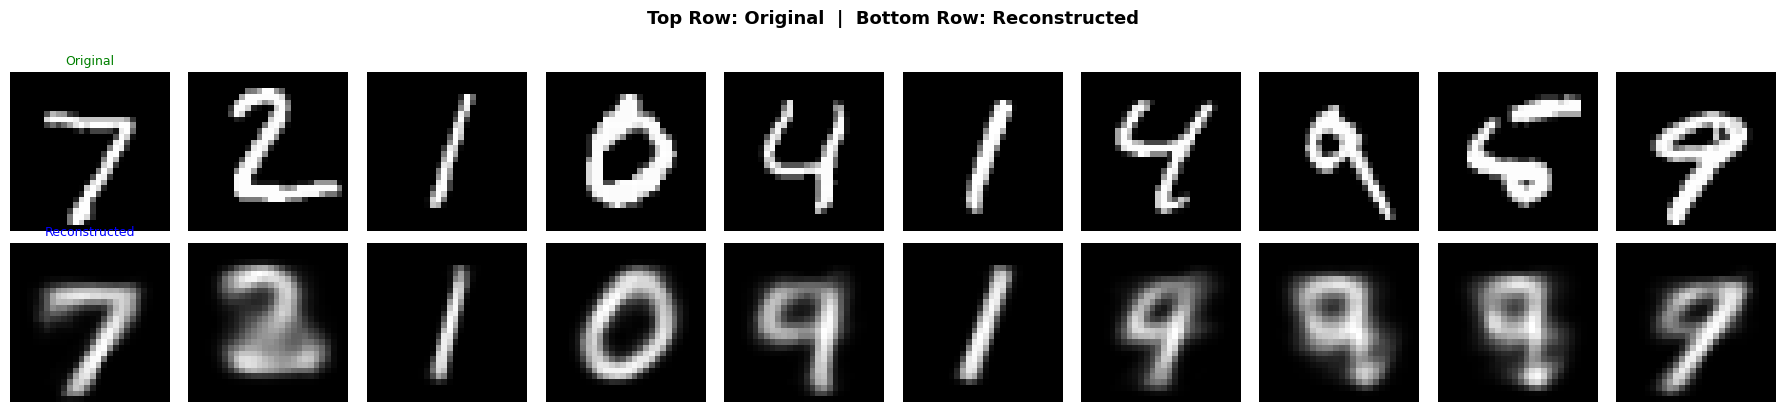

Reconstruction comparison saved.


In [10]:
model.eval()
with torch.no_grad():
    sample_imgs, _ = next(iter(test_loader))
    sample_imgs = sample_imgs[:10].to(device)
    recon_imgs, _, _ = model(sample_imgs)
    recon_imgs = recon_imgs.view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Top Row: Original  |  Bottom Row: Reconstructed",
             fontsize=13, fontweight='bold', y=1.02)

for i in range(10):
    # Original
    axes[0, i].imshow(sample_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Original", fontsize=9, color='green')

    # Reconstructed
    axes[1, i].imshow(recon_imgs[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Reconstructed", fontsize=9, color='blue')

plt.tight_layout()
plt.savefig("vae_reconstruction.png", dpi=150)
plt.show()
print("Reconstruction comparison saved.")

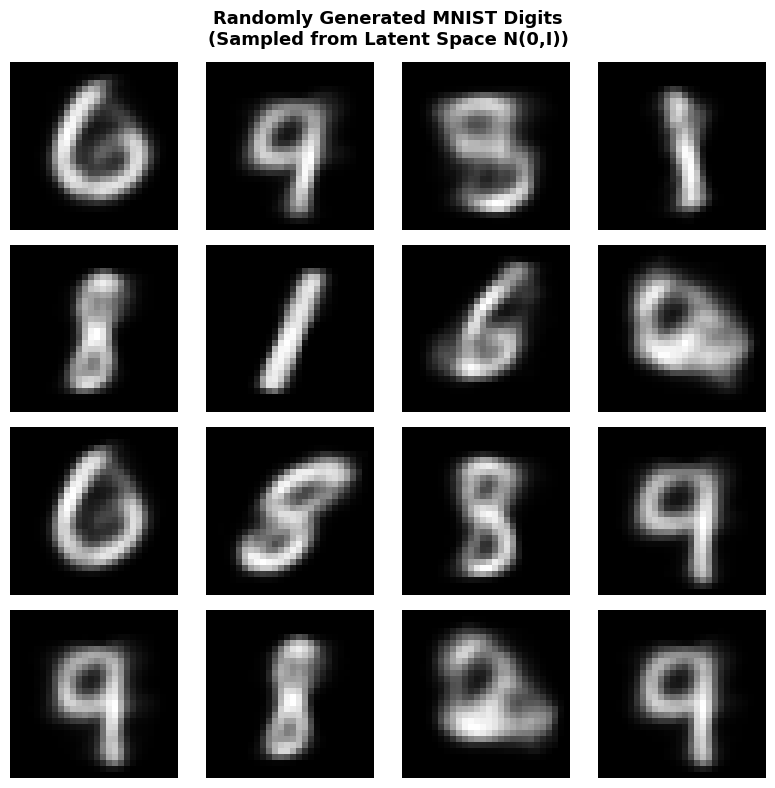

Generated samples saved.


In [11]:
model.eval()
with torch.no_grad():
    # Sample random latent vectors from N(0, I)
    z_random = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decoder(z_random).view(-1, 1, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Randomly Generated MNIST Digits\n(Sampled from Latent Space N(0,I))",
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig("vae_generated_samples.png", dpi=150)
plt.show()
print("Generated samples saved.")

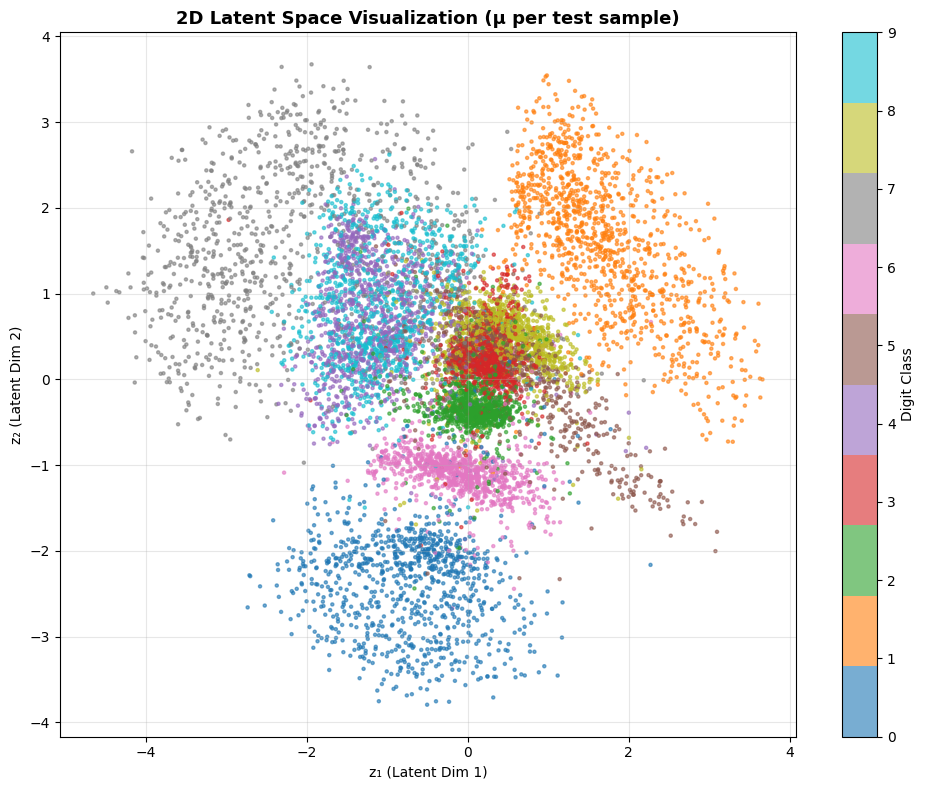

2D latent space plot saved.


In [12]:
# Only works when LATENT_DIM = 2
if LATENT_DIM == 2:
    model.eval()
    all_mu, all_labels = [], []

    with torch.no_grad():
        for x, labels in test_loader:
            x = x.to(device)
            x_flat = x.view(x.size(0), -1)
            mu, _ = model.encoder(x_flat)
            all_mu.append(mu.cpu().numpy())
            all_labels.append(labels.numpy())

    all_mu     = np.concatenate(all_mu,     axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1],
                          c=all_labels, cmap='tab10',
                          alpha=0.6, s=5)
    plt.colorbar(scatter, label='Digit Class')
    plt.title("2D Latent Space Visualization (μ per test sample)",
              fontsize=13, fontweight='bold')
    plt.xlabel("z₁ (Latent Dim 1)")
    plt.ylabel("z₂ (Latent Dim 2)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("vae_latent_space_2d.png", dpi=150)
    plt.show()
    print("2D latent space plot saved.")
else:
    print(f"LATENT_DIM={LATENT_DIM}. Set LATENT_DIM=2 and retrain to see the 2D latent space.")